In [7]:
from __future__ import print_function
import os
import sys

# Temporary workaround for Windows OpenMP duplicate runtime initialization in notebooks.
# Must be set before importing torch/torchvision/numpy-linked libraries.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

# Set up absolute path to the root of the project for importing custom modules.
sys.path.append(os.path.abspath("../.."))

import numpy as np
import torch as torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, ConcatDataset
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import pickle

from utils.train_val_utils import train_and_evaluate
from utils.test_utils import evaluate_split
from models.ConViT.ConVit import ViT, ConvViTProcessor

torch.manual_seed(42)
use_cuda = True
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if (use_cuda and torch.cuda.is_available()) else "cpu")
print(f"Using device: {device}")

CUDA available: True
Using device: cuda


In [6]:
torch.manual_seed(42)
def flip_target(y): 
    return 1 - y

transforms_resize = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = ImageFolder(root="../../butterfly_anomaly_image_resized/final_dataset/train", target_transform=flip_target, transform=transforms_resize)
print("Classes:", train_dataset.classes)
print("Class->idx:", train_dataset.class_to_idx)
print("Total:", len(train_dataset))

val_dataset = ImageFolder(root="../../butterfly_anomaly_image_resized/final_dataset/val", target_transform=flip_target, transform=transforms_resize)
print("Classes:", val_dataset.classes)
print("Class->idx:", val_dataset.class_to_idx)
print("Total:", len(val_dataset))
test_dataset = ImageFolder(root="../../butterfly_anomaly_image_resized/final_dataset/test", target_transform=flip_target, transform=transforms_resize)
print("Classes:", test_dataset.classes)
print("Class->idx:", test_dataset.class_to_idx)
print("Total:", len(test_dataset))

Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 3538
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 442
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 444


In [ ]:
torch.manual_seed(42)
#Add Augmented Images to Dataset
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

num_aug = 1500
# Rebuild datasets from the SAME split folders, only changing transforms
aug_train_dataset = ImageFolder(root="../../butterfly_anomaly_image_resized/final_dataset/train", transform=transform_train)

# Optional sanity check: class mapping must match across splits
assert aug_train_dataset.class_to_idx == val_dataset.class_to_idx == test_dataset.class_to_idx

## Models

In [12]:
img_size = 224
batch_size = 16

# Parameters for model
patch_size = 8
embed_dim = 64
padding = 2
num_patches = (img_size//patch_size)**2
num_classes = 2
num_heads = 2
num_layers = 1
mlp_dim = 128
class_weight = 3.5
weight_decay = 1e-3

# Hyperparameters
epochs = 25
lr = 1e-4
dropout = 0.2

vi_processor = ConvViTProcessor(img_size = img_size, patch_size = patch_size, embed_dim = embed_dim, device = device, padding=padding)

model_init = ViT(embed_dim = embed_dim, num_patches = num_patches, num_classes = num_classes, 
            num_heads = num_heads, num_layers = num_layers, mlp_dim = mlp_dim, dropout=dropout).to(device)

optimizer = optim.Adam(model_init.parameters(), lr = lr, weight_decay=weight_decay)

print(model_init)

ViT(
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (mlp_head): Sequential(
    (0): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [ ]:
#Test Evaluate
print("="*20)
print("Model Initial Training")
print("="*20)
results_init = train_and_evaluate(model_init, train_set=aug_train_dataset, val_set=val_dataset, 
optimizer=optimizer, num_epochs = epochs, batch_size = batch_size, class_weights_val = class_weight, 
    ckpt_file = '../../saved_models/conv_vit/vit_model_init.pkl', device=device, embeddings = vi_processor.process_images, num_workers=0)

Model Initial Training
  [Epoch 1] Improvement! New best score: 0.053619
  [Epoch 2] Improvement! New best score: 0.188679
  [Epoch 3] Improvement! New best score: 0.269762
  [Epoch 5] Improvement! New best score: 0.303495
Epoch [5/25], Train Loss: 0.4643, Val Loss: 2.2945, Train F1-Macro: 0.6527, Val F1-Macro: 0.2362, Train F1-Per-Class: [0.79446006 0.51098377], Val F1-Per-Class: [0.09444445 0.3778626 ], Train F2-Macro: 0.7051, Val F2-Macro: 0.2251, Train F2-Per-Class: [0.71475005 0.6955278 ], Val F2-Per-Class: [0.14680484 0.30349478], No improvement: 0/6
Epoch [5/25], Train Loss: 0.4643, Val Loss: 2.2945, Train F1-Macro: 0.6527, Val F1-Macro: 0.2362, Train F1-Per-Class: [0.79446006 0.51098377], Val F1-Per-Class: [0.09444445 0.3778626 ] Train F2-Macro: 0.7051, Val F2-Macro: 0.2251, Train F2-Per-Class: [0.71475005 0.6955278 ], Val F2-Per-Class: [0.14680484 0.30349478]
  [Epoch 6] Improvement! New best score: 0.321993
Epoch [10/25], Train Loss: 0.4437, Val Loss: 2.9137, Train F1-Macro: 

In [ ]:
## CHECK MODEL INIT
# -------------------------------------------
ckpt_file = "../../saved_models/conv_vit/vit_model_init.pkl"
hist = model_init.load_checkpoint_history(ckpt_file)

valid = [
r for r in hist
if r.get("metrics", {}).get("val_f2_per_class_history")
and len(r["metrics"]["val_f2_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f2_per_class_history"][-1][1])
)

print(len(valid))
print("F2 over time:", [i["metrics"]["val_f2_per_class_history"] for i in valid])
print("Selected epoch:", best["epoch"])
print("Best Train & Val Loss: {} and {}".format(float(best["metrics"]["train_loss_history"][-1]), float(best["metrics"]["val_loss_history"][-1])))
print("Best val F2 (class 0):", float(best["metrics"]["val_f2_per_class_history"][-1][0]))
print("Best val F2 (class 1):", float(best["metrics"]["val_f2_per_class_history"][-1][1]))

41
F2 over time: [[array([0.5259366 , 0.13192612], dtype=float32)], [array([0.5259366 , 0.13192612], dtype=float32), array([0.48435172, 0.17868745], dtype=float32)], [array([0.5259366 , 0.13192612], dtype=float32), array([0.48435172, 0.17868745], dtype=float32), array([0.47368422, 0.19093852], dtype=float32)], [array([0.5259366 , 0.13192612], dtype=float32), array([0.48435172, 0.17868745], dtype=float32), array([0.47368422, 0.19093852], dtype=float32), array([0.29983792, 0.2542373 ], dtype=float32)], [array([0.5259366 , 0.13192612], dtype=float32), array([0.48435172, 0.17868745], dtype=float32), array([0.47368422, 0.19093852], dtype=float32), array([0.29983792, 0.2542373 ], dtype=float32), array([0.23966943, 0.2647975 ], dtype=float32)], [array([0.5259366 , 0.13192612], dtype=float32), array([0.48435172, 0.17868745], dtype=float32), array([0.47368422, 0.19093852], dtype=float32), array([0.29983792, 0.2542373 ], dtype=float32), array([0.23966943, 0.2647975 ], dtype=float32), array([0.23

In [ ]:
# MODEL 1
#----------------------------------
img_size = 224
batch_size = 16

# Parameters for model
patch_size = 8
embed_dim = 64
padding = 2
num_patches = (img_size//patch_size)**2
num_classes = 2
num_heads = 2
num_layers = 1
mlp_dim = 128
class_weight = 5
weight_decay = 1e-3

# Hyperparameters
epochs = 25
lr = 1e-4
dropout = 0.2

vi_processor = ConvViTProcessor(img_size = img_size, patch_size = patch_size, embed_dim = embed_dim, device = device, padding=padding)

model_1 = ViT(embed_dim = embed_dim, num_patches = num_patches, num_classes = num_classes, 
            num_heads = num_heads, num_layers = num_layers, mlp_dim = mlp_dim, dropout=dropout).to(device)

optimizer = optim.Adam(model_1.parameters(), lr = lr, weight_decay=weight_decay)

print("="*20)
print("Model 1 Training")
print("="*20)
results_init = train_and_evaluate(model_1, train_set=aug_train_dataset, val_set=val_dataset, 
optimizer=optimizer, num_epochs = epochs, batch_size = batch_size, class_weights_val = class_weight, 
    ckpt_file = '../../saved_models/conv_vit/vit_model_1.pkl', device=device, embeddings = vi_processor.process_images, num_workers=0)

Model 1 Training
  [Epoch 1] Improvement! New best score: 0.102853
  [Epoch 2] Improvement! New best score: 0.170157
  [Epoch 3] Improvement! New best score: 0.254019
Epoch [5/25], Train Loss: 0.5280, Val Loss: 1.4398, Train F1-Macro: 0.5834, Val F1-Macro: 0.3073, Train F1-Per-Class: [0.72527933 0.44149163], Val F1-Per-Class: [0.32300884 0.29166666], Train F2-Macro: 0.6312, Val F2-Macro: 0.3743, Train F2-Per-Class: [0.63212055 0.63035494], Val F2-Per-Class: [0.5439642  0.20467836], No improvement: 2/6
Epoch [5/25], Train Loss: 0.5280, Val Loss: 1.4398, Train F1-Macro: 0.5834, Val F1-Macro: 0.3073, Train F1-Per-Class: [0.72527933 0.44149163], Val F1-Per-Class: [0.32300884 0.29166666] Train F2-Macro: 0.6312, Val F2-Macro: 0.3743, Train F2-Per-Class: [0.63212055 0.63035494], Val F2-Per-Class: [0.5439642  0.20467836]

Early stopping at epoch 9. No improvement for 6 epochs.
Restored model weights from best epoch (score: 0.254019)


In [ ]:
## CHECK MODEL 1
# -------------------------------------------
ckpt_file = "../../saved_models/conv_vit/vit_model_1.pkl"
hist = model_1.load_checkpoint_history(ckpt_file)

valid = [
r for r in hist
if r.get("metrics", {}).get("val_f2_per_class_history")
and len(r["metrics"]["val_f2_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f2_per_class_history"][-1][1])
)

print(len(valid))
print("F2 over time:", [i["metrics"]["val_f2_per_class_history"] for i in valid])
print("Selected epoch:", best["epoch"])
print("Best Train & Val Loss: {} and {}".format(float(best["metrics"]["train_loss_history"][-1]), float(best["metrics"]["val_loss_history"][-1])))
print("Best val F2 (class 0):", float(best["metrics"]["val_f2_per_class_history"][-1][0]))
print("Best val F2 (class 1):", float(best["metrics"]["val_f2_per_class_history"][-1][1]))

9
F2 over time: [[array([0.5192034 , 0.10285335], dtype=float32)], [array([0.5192034 , 0.10285335], dtype=float32), array([0.53519064, 0.17015707], dtype=float32)], [array([0.5192034 , 0.10285335], dtype=float32), array([0.53519064, 0.17015707], dtype=float32), array([0.55725193, 0.2540193 ], dtype=float32)], [array([0.5192034 , 0.10285335], dtype=float32), array([0.53519064, 0.17015707], dtype=float32), array([0.55725193, 0.2540193 ], dtype=float32), array([0.541543 , 0.1953125], dtype=float32)], [array([0.5192034 , 0.10285335], dtype=float32), array([0.53519064, 0.17015707], dtype=float32), array([0.55725193, 0.2540193 ], dtype=float32), array([0.541543 , 0.1953125], dtype=float32), array([0.5439642 , 0.20467836], dtype=float32)], [array([0.5192034 , 0.10285335], dtype=float32), array([0.53519064, 0.17015707], dtype=float32), array([0.55725193, 0.2540193 ], dtype=float32), array([0.541543 , 0.1953125], dtype=float32), array([0.5439642 , 0.20467836], dtype=float32), array([0.53333336,

In [ ]:
# MODEL 2
#----------------------------------
img_size = 224
batch_size = 16

# Parameters for model
patch_size = 8
embed_dim = 64
padding = 2
num_patches = (img_size//patch_size)**2
num_classes = 2
num_heads = 2
num_layers = 1
mlp_dim = 128
class_weight = 6.5
weight_decay = 1e-3

# Hyperparameters
epochs = 25
lr = 1e-4
dropout = 0.2

vi_processor = ConvViTProcessor(img_size = img_size, patch_size = patch_size, embed_dim = embed_dim, device = device, padding=padding)

model_2 = ViT(embed_dim = embed_dim, num_patches = num_patches, num_classes = num_classes, 
            num_heads = num_heads, num_layers = num_layers, mlp_dim = mlp_dim, dropout=dropout).to(device)

optimizer = optim.Adam(model_2.parameters(), lr = lr, weight_decay=weight_decay)

print("="*20)
print("Model 2 Training")
print("="*20)
results_init = train_and_evaluate(model_2, train_set=aug_train_dataset, val_set=val_dataset, 
optimizer=optimizer, num_epochs = epochs, batch_size = batch_size, class_weights_val = class_weight, 
    ckpt_file = '../../saved_models/conv_vit/vit_model_2.pkl', device=device, embeddings = vi_processor.process_images, num_workers=0)

Model 2 Training
  [Epoch 1] Improvement! New best score: 0.768179
Epoch [5/25], Train Loss: 0.5422, Val Loss: 1.2547, Train F1-Macro: 0.5362, Val F1-Macro: 0.3730, Train F1-Per-Class: [0.6483041  0.42415208], Val F1-Per-Class: [0.33333334 0.41276595], Train F2-Macro: 0.5893, Val F2-Macro: 0.4263, Train F2-Per-Class: [0.5371558  0.64148813], Val F2-Per-Class: [0.5450237  0.30754596], No improvement: 4/6
Epoch [5/25], Train Loss: 0.5422, Val Loss: 1.2547, Train F1-Macro: 0.5362, Val F1-Macro: 0.3730, Train F1-Per-Class: [0.6483041  0.42415208], Val F1-Per-Class: [0.33333334 0.41276595] Train F2-Macro: 0.5893, Val F2-Macro: 0.4263, Train F2-Per-Class: [0.5371558  0.64148813], Val F2-Per-Class: [0.5450237  0.30754596]

Early stopping at epoch 7. No improvement for 6 epochs.
Restored model weights from best epoch (score: 0.768179)


In [ ]:
## CHECK MODEL 2
# -------------------------------------------
ckpt_file = "../../saved_models/conv_vit/vit_model_2.pkl"
hist = model_2.load_checkpoint_history(ckpt_file)

valid = [
r for r in hist
if r.get("metrics", {}).get("val_f2_per_class_history")
and len(r["metrics"]["val_f2_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f2_per_class_history"][-1][1])
)

print(len(valid))
print("F2 over time:", [i["metrics"]["val_f2_per_class_history"] for i in valid])
print("Selected epoch:", best["epoch"])
print("Best Train & Val Loss: {} and {}".format(float(best["metrics"]["train_loss_history"][-1]), float(best["metrics"]["val_loss_history"][-1])))
print("Best val F2 (class 0):", float(best["metrics"]["val_f2_per_class_history"][-1][0]))
print("Best val F2 (class 1):", float(best["metrics"]["val_f2_per_class_history"][-1][1]))

7
F2 over time: [[array([0.01312336, 0.76817936], dtype=float32)], [array([0.01312336, 0.76817936], dtype=float32), array([0.01061571, 0.5491662 ], dtype=float32)], [array([0.01312336, 0.76817936], dtype=float32), array([0.01061571, 0.5491662 ], dtype=float32), array([0.56426334, 0.30216286], dtype=float32)], [array([0.01312336, 0.76817936], dtype=float32), array([0.01061571, 0.5491662 ], dtype=float32), array([0.56426334, 0.30216286], dtype=float32), array([0.5259366 , 0.13192612], dtype=float32)], [array([0.01312336, 0.76817936], dtype=float32), array([0.01061571, 0.5491662 ], dtype=float32), array([0.56426334, 0.30216286], dtype=float32), array([0.5259366 , 0.13192612], dtype=float32), array([0.5450237 , 0.30754596], dtype=float32)], [array([0.01312336, 0.76817936], dtype=float32), array([0.01061571, 0.5491662 ], dtype=float32), array([0.56426334, 0.30216286], dtype=float32), array([0.5259366 , 0.13192612], dtype=float32), array([0.5450237 , 0.30754596], dtype=float32), array([0.550

In [ ]:
# MODEL 3
#----------------------------------
img_size = 224
batch_size = 16

# Parameters for model
patch_size = 8
embed_dim = 64
padding = 2
num_patches = (img_size//patch_size)**2
num_classes = 2
num_heads = 2
num_layers = 1
mlp_dim = 128
class_weight = 6.5
weight_decay = 1e-3

# Hyperparameters
epochs = 25
lr = 1e-5
dropout = 0.2

vi_processor = ConvViTProcessor(img_size = img_size, patch_size = patch_size, embed_dim = embed_dim, device = device, padding=padding)

model_3 = ViT(embed_dim = embed_dim, num_patches = num_patches, num_classes = num_classes, 
            num_heads = num_heads, num_layers = num_layers, mlp_dim = mlp_dim, dropout=dropout).to(device)

optimizer = optim.Adam(model_3.parameters(), lr = lr, weight_decay=weight_decay)

print("="*20)
print("Model 3 Training")
print("="*20)
results_init = train_and_evaluate(model_3, train_set=aug_train_dataset, val_set=val_dataset, 
optimizer=optimizer, num_epochs = epochs, batch_size = batch_size, class_weights_val = class_weight, 
    ckpt_file = '../../saved_models/conv_vit/vit_model_3.pkl', device=device, embeddings = vi_processor.process_images, num_workers=0)

Model 3 Training
  [Epoch 1] Improvement! New best score: 0.000000
  [Epoch 2] Improvement! New best score: 0.206452
  [Epoch 3] Improvement! New best score: 0.959833
Epoch [5/25], Train Loss: 0.6827, Val Loss: 0.6723, Train F1-Macro: 0.3901, Val F1-Macro: 0.4516, Train F1-Per-Class: [0.42921647 0.35095137], Val F1-Per-Class: [0.02105263 0.88212925], Train F2-Macro: 0.4469, Val F2-Macro: 0.4668, Train F2-Per-Class: [0.31994933 0.57377046], Val F2-Per-Class: [0.01592357 0.9177215 ], No improvement: 2/6
Epoch [5/25], Train Loss: 0.6827, Val Loss: 0.6723, Train F1-Macro: 0.3901, Val F1-Macro: 0.4516, Train F1-Per-Class: [0.42921647 0.35095137], Val F1-Per-Class: [0.02105263 0.88212925] Train F2-Macro: 0.4469, Val F2-Macro: 0.4668, Train F2-Per-Class: [0.31994933 0.57377046], Val F2-Per-Class: [0.01592357 0.9177215 ]

Early stopping at epoch 9. No improvement for 6 epochs.
Restored model weights from best epoch (score: 0.959833)


In [ ]:
## CHECK MODEL 3
# -------------------------------------------
ckpt_file = "../../saved_models/conv_vit/vit_model_3.pkl"
hist = model_3.load_checkpoint_history(ckpt_file)

valid = [
r for r in hist
if r.get("metrics", {}).get("val_f2_per_class_history")
and len(r["metrics"]["val_f2_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f2_per_class_history"][-1][1])
)

print(len(valid))
print("F2 over time:", [i["metrics"]["val_f2_per_class_history"] for i in valid])
print("Selected epoch:", best["epoch"])
print("Best Train & Val Loss: {} and {}".format(float(best["metrics"]["train_loss_history"][-1]), float(best["metrics"]["val_loss_history"][-1])))
print("Best val F2 (class 0):", float(best["metrics"]["val_f2_per_class_history"][-1][0]))
print("Best val F2 (class 1):", float(best["metrics"]["val_f2_per_class_history"][-1][1]))

9
F2 over time: [[array([0.4972752, 0.       ], dtype=float32)], [array([0.4972752, 0.       ], dtype=float32), array([0.47727272, 0.20645161], dtype=float32)], [array([0.4972752, 0.       ], dtype=float32), array([0.47727272, 0.20645161], dtype=float32), array([0.       , 0.9598331], dtype=float32)], [array([0.4972752, 0.       ], dtype=float32), array([0.47727272, 0.20645161], dtype=float32), array([0.       , 0.9598331], dtype=float32), array([0.01612903, 0.9263158 ], dtype=float32)], [array([0.4972752, 0.       ], dtype=float32), array([0.47727272, 0.20645161], dtype=float32), array([0.       , 0.9598331], dtype=float32), array([0.01612903, 0.9263158 ], dtype=float32), array([0.01592357, 0.9177215 ], dtype=float32)], [array([0.4972752, 0.       ], dtype=float32), array([0.47727272, 0.20645161], dtype=float32), array([0.       , 0.9598331], dtype=float32), array([0.01612903, 0.9263158 ], dtype=float32), array([0.01592357, 0.9177215 ], dtype=float32), array([0.01567398, 0.9069275 ], 

In [ ]:
# MODEL 4
#----------------------------------
img_size = 224
batch_size = 16

# Parameters for model
patch_size = 8
embed_dim = 64
padding = 2
num_patches = (img_size//patch_size)**2
num_classes = 2
num_heads = 2
num_layers = 1
mlp_dim = 128
class_weight = 6.5
weight_decay = 1e-3

# Hyperparameters
epochs = 25
lr = 5e-4
dropout = 0.2

vi_processor = ConvViTProcessor(img_size = img_size, patch_size = patch_size, embed_dim = embed_dim, device = device, padding=padding)

model_4 = ViT(embed_dim = embed_dim, num_patches = num_patches, num_classes = num_classes, 
            num_heads = num_heads, num_layers = num_layers, mlp_dim = mlp_dim, dropout=dropout).to(device)

optimizer = optim.Adam(model_4.parameters(), lr = lr, weight_decay=weight_decay)

print("="*20)
print("Model 4 Training")
print("="*20)
results_init = train_and_evaluate(model_4, train_set=aug_train_dataset, val_set=val_dataset, 
optimizer=optimizer, num_epochs = epochs, batch_size = batch_size, class_weights_val = class_weight, 
    ckpt_file = '../../saved_models/conv_vit/vit_model_4.pkl', device=device, embeddings = vi_processor.process_images, num_workers=0)

Model 4 Training
  [Epoch 1] Improvement! New best score: 0.318568
Epoch [5/25], Train Loss: 0.3829, Val Loss: 2.5052, Train F1-Macro: 0.7513, Val F1-Macro: 0.1773, Train F1-Per-Class: [0.87815833 0.62435085], Val F1-Per-Class: [0.04324324 0.31128404], Train F2-Macro: 0.8010, Val F2-Macro: 0.1573, Train F2-Per-Class: [0.82576555 0.77618366], Val F2-Per-Class: [0.06791171 0.24676126], No improvement: 4/6
Epoch [5/25], Train Loss: 0.3829, Val Loss: 2.5052, Train F1-Macro: 0.7513, Val F1-Macro: 0.1773, Train F1-Per-Class: [0.87815833 0.62435085], Val F1-Per-Class: [0.04324324 0.31128404] Train F2-Macro: 0.8010, Val F2-Macro: 0.1573, Train F2-Per-Class: [0.82576555 0.77618366], Val F2-Per-Class: [0.06791171 0.24676126]

Early stopping at epoch 7. No improvement for 6 epochs.
Restored model weights from best epoch (score: 0.318568)


In [ ]:
## CHECK MODEL 4
# -------------------------------------------
ckpt_file = "../../saved_models/conv_vit/vit_model_4.pkl"
hist = model_4.load_checkpoint_history(ckpt_file)

valid = [
r for r in hist
if r.get("metrics", {}).get("val_f2_per_class_history")
and len(r["metrics"]["val_f2_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f2_per_class_history"][-1][1])
)

print(len(valid))
print("F2 over time:", [i["metrics"]["val_f2_per_class_history"] for i in valid])
print("Selected epoch:", best["epoch"])
print("Best Train & Val Loss: {} and {}".format(float(best["metrics"]["train_loss_history"][-1]), float(best["metrics"]["val_loss_history"][-1])))
print("Best val F2 (class 0):", float(best["metrics"]["val_f2_per_class_history"][-1][0]))
print("Best val F2 (class 1):", float(best["metrics"]["val_f2_per_class_history"][-1][1]))

9
F2 over time: [[array([0.07434944, 0.3917464 ], dtype=float32)], [array([0.07434944, 0.3917464 ], dtype=float32), array([0.14134276, 0.33759123], dtype=float32)], [array([0.05338078, 0.31856796], dtype=float32)], [array([0.05338078, 0.31856796], dtype=float32), array([0.06768189, 0.24088944], dtype=float32)], [array([0.05338078, 0.31856796], dtype=float32), array([0.06768189, 0.24088944], dtype=float32), array([0.09966777, 0.22077115], dtype=float32)], [array([0.05338078, 0.31856796], dtype=float32), array([0.06768189, 0.24088944], dtype=float32), array([0.09966777, 0.22077115], dtype=float32), array([0.04340278, 0.2753978 ], dtype=float32)], [array([0.05338078, 0.31856796], dtype=float32), array([0.06768189, 0.24088944], dtype=float32), array([0.09966777, 0.22077115], dtype=float32), array([0.04340278, 0.2753978 ], dtype=float32), array([0.06791171, 0.24676126], dtype=float32)], [array([0.05338078, 0.31856796], dtype=float32), array([0.06768189, 0.24088944], dtype=float32), array([0

In [ ]:
# MODEL 5
#----------------------------------
img_size = 224
batch_size = 16

# Parameters for model
patch_size = 8
embed_dim = 64
padding = 2
num_patches = (img_size//patch_size)**2
num_classes = 2
num_heads = 2
num_layers = 1
mlp_dim = 128
class_weight = 6.5
weight_decay = 1e-3

# Hyperparameters
epochs = 25
lr = 1e-4
dropout = 0.1

vi_processor = ConvViTProcessor(img_size = img_size, patch_size = patch_size, embed_dim = embed_dim, device = device, padding=padding)

model_5 = ViT(embed_dim = embed_dim, num_patches = num_patches, num_classes = num_classes, 
            num_heads = num_heads, num_layers = num_layers, mlp_dim = mlp_dim, dropout=dropout).to(device)

optimizer = optim.Adam(model_5.parameters(), lr = lr, weight_decay=weight_decay)

print("="*20)
print("Model 5 Training")
print("="*20)
results_init = train_and_evaluate(model_5, train_set=aug_train_dataset, val_set=val_dataset, 
optimizer=optimizer, num_epochs = epochs, batch_size = batch_size, class_weights_val = class_weight, 
    ckpt_file = '../../saved_models/conv_vit/vit_model_5.pkl', device=device, embeddings = vi_processor.process_images, num_workers=0)

Model 5 Training
  [Epoch 1] Improvement! New best score: 0.383004
Epoch [5/25], Train Loss: 0.4190, Val Loss: 1.7711, Train F1-Macro: 0.7238, Val F1-Macro: 0.2131, Train F1-Per-Class: [0.85844576 0.5890789 ], Val F1-Per-Class: [0.03508772 0.39114392], Train F2-Macro: 0.7743, Val F2-Macro: 0.1874, Train F2-Per-Class: [0.799646  0.7489481], Val F2-Per-Class: [0.05347594 0.3214069 ], No improvement: 4/6
Epoch [5/25], Train Loss: 0.4190, Val Loss: 1.7711, Train F1-Macro: 0.7238, Val F1-Macro: 0.2131, Train F1-Per-Class: [0.85844576 0.5890789 ], Val F1-Per-Class: [0.03508772 0.39114392] Train F2-Macro: 0.7743, Val F2-Macro: 0.1874, Train F2-Per-Class: [0.799646  0.7489481], Val F2-Per-Class: [0.05347594 0.3214069 ]

Early stopping at epoch 7. No improvement for 6 epochs.
Restored model weights from best epoch (score: 0.383004)


In [ ]:
## CHECK MODEL 5
# -------------------------------------------
ckpt_file = "../../saved_models/conv_vit/vit_model_5.pkl"
hist = model_5.load_checkpoint_history(ckpt_file)

valid = [
r for r in hist
if r.get("metrics", {}).get("val_f2_per_class_history")
and len(r["metrics"]["val_f2_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f2_per_class_history"][-1][1])
)

print(len(valid))
print("F2 over time:", [i["metrics"]["val_f2_per_class_history"] for i in valid])
print("Selected epoch:", best["epoch"])
print("Best Train & Val Loss: {} and {}".format(float(best["metrics"]["train_loss_history"][-1]), float(best["metrics"]["val_loss_history"][-1])))
print("Best val F2 (class 0):", float(best["metrics"]["val_f2_per_class_history"][-1][0]))
print("Best val F2 (class 1):", float(best["metrics"]["val_f2_per_class_history"][-1][1]))

7
F2 over time: [[array([0.05565863, 0.3830042 ], dtype=float32)], [array([0.05565863, 0.3830042 ], dtype=float32), array([0.0528169 , 0.30146164], dtype=float32)], [array([0.05565863, 0.3830042 ], dtype=float32), array([0.0528169 , 0.30146164], dtype=float32), array([0.05395683, 0.3355502 ], dtype=float32)], [array([0.05565863, 0.3830042 ], dtype=float32), array([0.0528169 , 0.30146164], dtype=float32), array([0.05395683, 0.3355502 ], dtype=float32), array([0.05319149, 0.3128797 ], dtype=float32)], [array([0.05565863, 0.3830042 ], dtype=float32), array([0.0528169 , 0.30146164], dtype=float32), array([0.05395683, 0.3355502 ], dtype=float32), array([0.05319149, 0.3128797 ], dtype=float32), array([0.05347594, 0.3214069 ], dtype=float32)], [array([0.05565863, 0.3830042 ], dtype=float32), array([0.0528169 , 0.30146164], dtype=float32), array([0.05395683, 0.3355502 ], dtype=float32), array([0.05319149, 0.3128797 ], dtype=float32), array([0.05347594, 0.3214069 ], dtype=float32), array([0.052

In [ ]:
# MODEL 6
#----------------------------------
img_size = 224
batch_size = 16

# Parameters for model
patch_size = 8
embed_dim = 64
padding = 2
num_patches = (img_size//patch_size)**2
num_classes = 2
num_heads = 2
num_layers = 1
mlp_dim = 128
class_weight = 6.5
weight_decay = 1e-3

# Hyperparameters
epochs = 25
lr = 1e-4
dropout = 0.4

vi_processor = ConvViTProcessor(img_size = img_size, patch_size = patch_size, embed_dim = embed_dim, device = device, padding=padding)

model_6 = ViT(embed_dim = embed_dim, num_patches = num_patches, num_classes = num_classes, 
            num_heads = num_heads, num_layers = num_layers, mlp_dim = mlp_dim, dropout=dropout).to(device)

optimizer = optim.Adam(model_6.parameters(), lr = lr, weight_decay=weight_decay)

print("="*20)
print("Model 6 Training")
print("="*20)
results_init = train_and_evaluate(model_6, train_set=aug_train_dataset, val_set=val_dataset, 
optimizer=optimizer, num_epochs = epochs, batch_size = batch_size, class_weights_val = class_weight, 
    ckpt_file = '../../saved_models/conv_vit/vit_model_6.pkl', device=device, embeddings = vi_processor.process_images, num_workers=0)

Model 6 Training
  [Epoch 1] Improvement! New best score: 0.754251
Epoch [5/25], Train Loss: 0.5183, Val Loss: 1.3140, Train F1-Macro: 0.5862, Val F1-Macro: 0.3075, Train F1-Per-Class: [0.724306   0.44802716], Val F1-Per-Class: [0.21818182 0.39679357], Train F2-Macro: 0.6358, Val F2-Macro: 0.3280, Train F2-Per-Class: [0.6291878 0.6424921], Val F2-Per-Class: [0.34768212 0.30821916], No improvement: 4/6
Epoch [5/25], Train Loss: 0.5183, Val Loss: 1.3140, Train F1-Macro: 0.5862, Val F1-Macro: 0.3075, Train F1-Per-Class: [0.724306   0.44802716], Val F1-Per-Class: [0.21818182 0.39679357] Train F2-Macro: 0.6358, Val F2-Macro: 0.3280, Train F2-Per-Class: [0.6291878 0.6424921], Val F2-Per-Class: [0.34768212 0.30821916]

Early stopping at epoch 7. No improvement for 6 epochs.
Restored model weights from best epoch (score: 0.754251)


In [ ]:
## CHECK MODEL 6
# -------------------------------------------
ckpt_file = "../../saved_models/conv_vit/vit_model_6.pkl"
hist = model_6.load_checkpoint_history(ckpt_file)

valid = [
r for r in hist
if r.get("metrics", {}).get("val_f2_per_class_history")
and len(r["metrics"]["val_f2_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f2_per_class_history"][-1][1])
)

print(len(valid))
print("F2 over time:", [i["metrics"]["val_f2_per_class_history"] for i in valid])
print("Selected epoch:", best["epoch"])
print("Best Train & Val Loss: {} and {}".format(float(best["metrics"]["train_loss_history"][-1]), float(best["metrics"]["val_loss_history"][-1])))
print("Best val F2 (class 0):", float(best["metrics"]["val_f2_per_class_history"][-1][0]))
print("Best val F2 (class 1):", float(best["metrics"]["val_f2_per_class_history"][-1][1]))

7
F2 over time: [[array([0.0129199 , 0.75425124], dtype=float32)], [array([0.0129199 , 0.75425124], dtype=float32), array([0.5263158 , 0.31585598], dtype=float32)], [array([0.0129199 , 0.75425124], dtype=float32), array([0.5263158 , 0.31585598], dtype=float32), array([0.51937985, 0.26517573], dtype=float32)], [array([0.0129199 , 0.75425124], dtype=float32), array([0.5263158 , 0.31585598], dtype=float32), array([0.51937985, 0.26517573], dtype=float32), array([0.5307692 , 0.25641027], dtype=float32)], [array([0.0129199 , 0.75425124], dtype=float32), array([0.5263158 , 0.31585598], dtype=float32), array([0.51937985, 0.26517573], dtype=float32), array([0.5307692 , 0.25641027], dtype=float32), array([0.34768212, 0.30821916], dtype=float32)], [array([0.0129199 , 0.75425124], dtype=float32), array([0.5263158 , 0.31585598], dtype=float32), array([0.51937985, 0.26517573], dtype=float32), array([0.5307692 , 0.25641027], dtype=float32), array([0.34768212, 0.30821916], dtype=float32), array([0.055

In [ ]:
# MODEL 7
#----------------------------------
img_size = 224
batch_size = 16
num_classes = 2

# Parameters for model
patch_size = 8
embed_dim = 64
padding = 2
num_patches = (img_size//patch_size)**2
num_heads = 2
num_layers = 2
mlp_dim = 128
class_weight = 6.5
weight_decay = 1e-3

# Hyperparameters
epochs = 25
lr = 1e-4
dropout = 0.2

vi_processor = ConvViTProcessor(img_size = img_size, patch_size = patch_size, embed_dim = embed_dim, device = device, padding=padding)

model_7 = ViT(embed_dim = embed_dim, num_patches = num_patches, num_classes = num_classes, 
            num_heads = num_heads, num_layers = num_layers, mlp_dim = mlp_dim, dropout=dropout).to(device)

optimizer = optim.Adam(model_7.parameters(), lr = lr, weight_decay=weight_decay)

print("="*20)
print("Model 7 Training")
print("="*20)
results_init = train_and_evaluate(model_7, train_set=aug_train_dataset, val_set=val_dataset, 
optimizer=optimizer, num_epochs = epochs, batch_size = batch_size, class_weights_val = class_weight, 
    ckpt_file = '../../saved_models/conv_vit/vit_model_7.pkl', device=device, embeddings = vi_processor.process_images, num_workers=0)

Model 7 Training
  [Epoch 1] Improvement! New best score: 0.351368
Epoch [5/25], Train Loss: 0.3739, Val Loss: 2.0268, Train F1-Macro: 0.6945, Val F1-Macro: 0.2038, Train F1-Per-Class: [0.82749116 0.5615616 ], Val F1-Per-Class: [0.03988604 0.36772984], Train F2-Macro: 0.7508, Val F2-Macro: 0.1801, Train F2-Per-Class: [0.7535868 0.748    ], Val F2-Per-Class: [0.06140351 0.2987805 ], No improvement: 4/6
Epoch [5/25], Train Loss: 0.3739, Val Loss: 2.0268, Train F1-Macro: 0.6945, Val F1-Macro: 0.2038, Train F1-Per-Class: [0.82749116 0.5615616 ], Val F1-Per-Class: [0.03988604 0.36772984] Train F2-Macro: 0.7508, Val F2-Macro: 0.1801, Train F2-Per-Class: [0.7535868 0.748    ], Val F2-Per-Class: [0.06140351 0.2987805 ]

Early stopping at epoch 7. No improvement for 6 epochs.
Restored model weights from best epoch (score: 0.351368)


In [61]:
## CHECK MODEL 7
# -------------------------------------------
ckpt_file = "saved_models/conv_vit/vit_model_7.pkl"
hist = model_7.load_checkpoint_history(ckpt_file)

valid = [
r for r in hist
if r.get("metrics", {}).get("val_f2_per_class_history")
and len(r["metrics"]["val_f2_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f2_per_class_history"][-1][1])
)

print(len(valid))
print("F2 over time:", [i["metrics"]["val_f2_per_class_history"] for i in valid])
print("Selected epoch:", best["epoch"])
print("Best Train & Val Loss: {} and {}".format(float(best["metrics"]["train_loss_history"][-1]), float(best["metrics"]["val_loss_history"][-1])))
print("Best val F2 (class 0):", float(best["metrics"]["val_f2_per_class_history"][-1][0]))
print("Best val F2 (class 1):", float(best["metrics"]["val_f2_per_class_history"][-1][1]))

7
F2 over time: [[array([0.44850498, 0.35136816], dtype=float32)], [array([0.44850498, 0.35136816], dtype=float32), array([0.34902596, 0.27603513], dtype=float32)], [array([0.44850498, 0.35136816], dtype=float32), array([0.34902596, 0.27603513], dtype=float32), array([0.23615634, 0.23809524], dtype=float32)], [array([0.44850498, 0.35136816], dtype=float32), array([0.34902596, 0.27603513], dtype=float32), array([0.23615634, 0.23809524], dtype=float32), array([0.25723472, 0.22355163], dtype=float32)], [array([0.44850498, 0.35136816], dtype=float32), array([0.34902596, 0.27603513], dtype=float32), array([0.23615634, 0.23809524], dtype=float32), array([0.25723472, 0.22355163], dtype=float32), array([0.06140351, 0.2987805 ], dtype=float32)], [array([0.44850498, 0.35136816], dtype=float32), array([0.34902596, 0.27603513], dtype=float32), array([0.23615634, 0.23809524], dtype=float32), array([0.25723472, 0.22355163], dtype=float32), array([0.06140351, 0.2987805 ], dtype=float32), array([0.272

In [ ]:
# MODEL 8
#----------------------------------
img_size = 224
batch_size = 16
num_classes = 2

# Parameters for model
patch_size = 8
embed_dim = 64
padding = 2
num_patches = (img_size//patch_size)**2
num_heads = 1
num_layers = 2
mlp_dim = 128
class_weight = 6.5
weight_decay = 1e-3

# Hyperparameters
epochs = 25
lr = 1e-4
dropout = 0.2

vi_processor = ConvViTProcessor(img_size = img_size, patch_size = patch_size, embed_dim = embed_dim, device = device, padding=padding)

model_8 = ViT(embed_dim = embed_dim, num_patches = num_patches, num_classes = num_classes, 
            num_heads = num_heads, num_layers = num_layers, mlp_dim = mlp_dim, dropout=dropout).to(device)

optimizer = optim.Adam(model_8.parameters(), lr = lr, weight_decay=weight_decay)

print("="*20)
print("Model 8 Training")
print("="*20)
results_init = train_and_evaluate(model_8, train_set=aug_train_dataset, val_set=val_dataset, 
optimizer=optimizer, num_epochs = epochs, batch_size = batch_size, class_weights_val = class_weight, 
    ckpt_file = '../../saved_models/conv_vit/vit_model_8.pkl', device=device, embeddings = vi_processor.process_images, num_workers=0)

Model 8 Training


C:\Users\Tente\AppData\Local\Temp\ipykernel_32776\2383437945.py:6: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.encoder = nn.TransformerEncoder(nn.TransformerEncoderLayer(d_model = embed_dim,


  [Epoch 1] Improvement! New best score: 0.290364
  [Epoch 2] Improvement! New best score: 0.453208
Epoch [5/25], Train Loss: 0.4282, Val Loss: 2.6549, Train F1-Macro: 0.7469, Val F1-Macro: 0.1556, Train F1-Per-Class: [0.8780488 0.6158358], Val F1-Per-Class: [0.04675325 0.26452905], Train F2-Macro: 0.7938, Val F2-Macro: 0.1400, Train F2-Per-Class: [0.8283566 0.7593289], Val F2-Per-Class: [0.07450331 0.20547946], No improvement: 3/6
Epoch [5/25], Train Loss: 0.4282, Val Loss: 2.6549, Train F1-Macro: 0.7469, Val F1-Macro: 0.1556, Train F1-Per-Class: [0.8780488 0.6158358], Val F1-Per-Class: [0.04675325 0.26452905] Train F2-Macro: 0.7938, Val F2-Macro: 0.1400, Train F2-Per-Class: [0.8283566 0.7593289], Val F2-Per-Class: [0.07450331 0.20547946]

Early stopping at epoch 8. No improvement for 6 epochs.
Restored model weights from best epoch (score: 0.453208)


In [ ]:
## CHECK MODEL 8
# -------------------------------------------
ckpt_file = "../../saved_models/conv_vit/vit_model_8.pkl"
hist = model_8.load_checkpoint_history(ckpt_file)

valid = [
r for r in hist
if r.get("metrics", {}).get("val_f2_per_class_history")
and len(r["metrics"]["val_f2_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f2_per_class_history"][-1][1])
)

print(len(valid))
print("F2 over time:", [i["metrics"]["val_f2_per_class_history"] for i in valid])
print("Selected epoch:", best["epoch"])
print("Best Train & Val Loss: {} and {}".format(float(best["metrics"]["train_loss_history"][-1]), float(best["metrics"]["val_loss_history"][-1])))
print("Best val F2 (class 0):", float(best["metrics"]["val_f2_per_class_history"][-1][0]))
print("Best val F2 (class 1):", float(best["metrics"]["val_f2_per_class_history"][-1][1]))

8
F2 over time: [[array([0.5676516 , 0.29036376], dtype=float32)], [array([0.5676516 , 0.29036376], dtype=float32), array([0.03913894, 0.45320776], dtype=float32)], [array([0.5676516 , 0.29036376], dtype=float32), array([0.03913894, 0.45320776], dtype=float32), array([0.04844961, 0.44273907], dtype=float32)], [array([0.5676516 , 0.29036376], dtype=float32), array([0.03913894, 0.45320776], dtype=float32), array([0.04844961, 0.44273907], dtype=float32), array([0.06205674, 0.31591737], dtype=float32)], [array([0.5676516 , 0.29036376], dtype=float32), array([0.03913894, 0.45320776], dtype=float32), array([0.04844961, 0.44273907], dtype=float32), array([0.06205674, 0.31591737], dtype=float32), array([0.07450331, 0.20547946], dtype=float32)], [array([0.5676516 , 0.29036376], dtype=float32), array([0.03913894, 0.45320776], dtype=float32), array([0.04844961, 0.44273907], dtype=float32), array([0.06205674, 0.31591737], dtype=float32), array([0.07450331, 0.20547946], dtype=float32), array([0.121

In [ ]:
# MODEL 9
#----------------------------------
img_size = 224
batch_size = 16
num_classes = 2

# Parameters for model
patch_size = 8
embed_dim = 64
padding = 4
num_patches = (img_size//patch_size)**2
num_heads = 2
num_layers = 1
mlp_dim = 128
class_weight = 6.5
weight_decay = 1e-3

# Hyperparameters
epochs = 25
lr = 1e-4
dropout = 0.2

vi_processor = ConvViTProcessor(img_size = img_size, patch_size = patch_size, embed_dim = embed_dim, device = device, padding=padding)

model_9 = ViT(embed_dim = embed_dim, num_patches = num_patches, num_classes = num_classes, 
            num_heads = num_heads, num_layers = num_layers, mlp_dim = mlp_dim, dropout=dropout).to(device)

optimizer = optim.Adam(model_9.parameters(), lr = lr, weight_decay=weight_decay)

print("="*20)
print("Model 9 Training")
print("="*20)
results_init = train_and_evaluate(model_9, train_set=aug_train_dataset, val_set=val_dataset, 
optimizer=optimizer, num_epochs = epochs, batch_size = batch_size, class_weights_val = class_weight, 
    ckpt_file = '../../saved_models/conv_vit/vit_model_9.pkl', device=device, embeddings = vi_processor.process_images, num_workers=0)

Model 9 Training
  [Epoch 1] Improvement! New best score: 0.787466
Epoch [5/25], Train Loss: 0.4900, Val Loss: 1.6881, Train F1-Macro: 0.6388, Val F1-Macro: 0.2909, Train F1-Per-Class: [0.78725964 0.49040306], Val F1-Per-Class: [0.22828785 0.35343036], Train F2-Macro: 0.6876, Val F2-Macro: 0.3187, Train F2-Per-Class: [0.7091815 0.6660584], Val F2-Per-Class: [0.3697749  0.26763225], No improvement: 4/6
Epoch [5/25], Train Loss: 0.4900, Val Loss: 1.6881, Train F1-Macro: 0.6388, Val F1-Macro: 0.2909, Train F1-Per-Class: [0.78725964 0.49040306], Val F1-Per-Class: [0.22828785 0.35343036] Train F2-Macro: 0.6876, Val F2-Macro: 0.3187, Train F2-Per-Class: [0.7091815 0.6660584], Val F2-Per-Class: [0.3697749  0.26763225]

Early stopping at epoch 7. No improvement for 6 epochs.
Restored model weights from best epoch (score: 0.787466)


In [ ]:
## CHECK MODEL 9
# -------------------------------------------
ckpt_file = "../../saved_models/conv_vit/vit_model_9.pkl"
hist = model_9.load_checkpoint_history(ckpt_file)

valid = [
r for r in hist
if r.get("metrics", {}).get("val_f2_per_class_history")
and len(r["metrics"]["val_f2_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f2_per_class_history"][-1][1])
)

print(len(valid))
print("F2 over time:", [i["metrics"]["val_f2_per_class_history"] for i in valid])
print("Selected epoch:", best["epoch"])
print("Best Train & Val Loss: {} and {}".format(float(best["metrics"]["train_loss_history"][-1]), float(best["metrics"]["val_loss_history"][-1])))
print("Best val F2 (class 0):", float(best["metrics"]["val_f2_per_class_history"][-1][0]))
print("Best val F2 (class 1):", float(best["metrics"]["val_f2_per_class_history"][-1][1]))

7
F2 over time: [[array([0.04      , 0.78746593], dtype=float32)], [array([0.04      , 0.78746593], dtype=float32), array([0.10067114, 0.6324447 ], dtype=float32)], [array([0.04      , 0.78746593], dtype=float32), array([0.10067114, 0.6324447 ], dtype=float32), array([0.44753087, 0.22727273], dtype=float32)], [array([0.04      , 0.78746593], dtype=float32), array([0.10067114, 0.6324447 ], dtype=float32), array([0.44753087, 0.22727273], dtype=float32), array([0.27118644, 0.31790122], dtype=float32)], [array([0.04      , 0.78746593], dtype=float32), array([0.10067114, 0.6324447 ], dtype=float32), array([0.44753087, 0.22727273], dtype=float32), array([0.27118644, 0.31790122], dtype=float32), array([0.3697749 , 0.26763225], dtype=float32)], [array([0.04      , 0.78746593], dtype=float32), array([0.10067114, 0.6324447 ], dtype=float32), array([0.44753087, 0.22727273], dtype=float32), array([0.27118644, 0.31790122], dtype=float32), array([0.3697749 , 0.26763225], dtype=float32), array([0.294

In [ ]:
# MODEL 10
#----------------------------------
img_size = 224
batch_size = 16
num_classes = 2

# Parameters for model
patch_size = 8
embed_dim = 64
padding = 6
num_patches = (img_size//patch_size)**2
num_heads = 2
num_layers = 1
mlp_dim = 128
class_weight = 6.5
weight_decay = 1e-3

# Hyperparameters
epochs = 25
lr = 1e-4
dropout = 0.2

vi_processor = ConvViTProcessor(img_size = img_size, patch_size = patch_size, embed_dim = embed_dim, device = device, padding=padding)

model_10 = ViT(embed_dim = embed_dim, num_patches = num_patches, num_classes = num_classes, 
            num_heads = num_heads, num_layers = num_layers, mlp_dim = mlp_dim, dropout=dropout).to(device)

optimizer = optim.Adam(model_10.parameters(), lr = lr, weight_decay=weight_decay)

print("="*20)
print("Model 10 Training")
print("="*20)
results_init = train_and_evaluate(model_10, train_set=aug_train_dataset, val_set=val_dataset, 
optimizer=optimizer, num_epochs = epochs, batch_size = batch_size, class_weights_val = class_weight, 
    ckpt_file = '../../saved_models/conv_vit/vit_model_10.pkl', device=device, embeddings = vi_processor.process_images, num_workers=0)

Model 10 Training
  [Epoch 1] Improvement! New best score: 0.056932
  [Epoch 2] Improvement! New best score: 0.339836
  [Epoch 4] Improvement! New best score: 0.391146
Epoch [5/25], Train Loss: 0.5282, Val Loss: 1.1046, Train F1-Macro: 0.5452, Val F1-Macro: 0.3711, Train F1-Per-Class: [0.66947836 0.42084792], Val F1-Per-Class: [0.28720626 0.4550898 ], Train F2-Macro: 0.5949, Val F2-Macro: 0.4056, Train F2-Per-Class: [0.5640757 0.6257229], Val F2-Per-Class: [0.45681062 0.3544776 ], No improvement: 1/6
Epoch [5/25], Train Loss: 0.5282, Val Loss: 1.1046, Train F1-Macro: 0.5452, Val F1-Macro: 0.3711, Train F1-Per-Class: [0.66947836 0.42084792], Val F1-Per-Class: [0.28720626 0.4550898 ] Train F2-Macro: 0.5949, Val F2-Macro: 0.4056, Train F2-Per-Class: [0.5640757 0.6257229], Val F2-Per-Class: [0.45681062 0.3544776 ]
Epoch [10/25], Train Loss: 0.4434, Val Loss: 1.3223, Train F1-Macro: 0.6322, Val F1-Macro: 0.2358, Train F1-Per-Class: [0.76796037 0.49641576], Val F1-Per-Class: [0.01277955 0.45

In [ ]:
## CHECK MODEL 10
# -------------------------------------------
ckpt_file = "../../saved_models/conv_vit/vit_model_10.pkl"
hist = model_10.load_checkpoint_history(ckpt_file)

valid = [
r for r in hist
if r.get("metrics", {}).get("val_f2_per_class_history")
and len(r["metrics"]["val_f2_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f2_per_class_history"][-1][1])
)

print(len(valid))
print("F2 over time:", [i["metrics"]["val_f2_per_class_history"] for i in valid])
print("Selected epoch:", best["epoch"])
print("Best Train & Val Loss: {} and {}".format(float(best["metrics"]["train_loss_history"][-1]), float(best["metrics"]["val_loss_history"][-1])))
print("Best val F2 (class 0):", float(best["metrics"]["val_f2_per_class_history"][-1][0]))
print("Best val F2 (class 1):", float(best["metrics"]["val_f2_per_class_history"][-1][1]))

10
F2 over time: [[array([0.50906557, 0.05693235], dtype=float32)], [array([0.50906557, 0.05693235], dtype=float32), array([0.547504 , 0.3398364], dtype=float32)], [array([0.50906557, 0.05693235], dtype=float32), array([0.547504 , 0.3398364], dtype=float32), array([0.5564388 , 0.32258064], dtype=float32)], [array([0.50906557, 0.05693235], dtype=float32), array([0.547504 , 0.3398364], dtype=float32), array([0.5564388 , 0.32258064], dtype=float32), array([0.25846702, 0.39114615], dtype=float32)], [array([0.50906557, 0.05693235], dtype=float32), array([0.547504 , 0.3398364], dtype=float32), array([0.5564388 , 0.32258064], dtype=float32), array([0.25846702, 0.39114615], dtype=float32), array([0.45681062, 0.3544776 ], dtype=float32)], [array([0.50906557, 0.05693235], dtype=float32), array([0.547504 , 0.3398364], dtype=float32), array([0.5564388 , 0.32258064], dtype=float32), array([0.25846702, 0.39114615], dtype=float32), array([0.45681062, 0.3544776 ], dtype=float32), array([0.3885135 , 0.

In [ ]:
# MODEL 11
#----------------------------------
img_size = 224
batch_size = 16
num_classes = 2

# Parameters for model
patch_size = 16
embed_dim = 64
padding = 4
num_patches = (img_size//patch_size)**2
num_heads = 2
num_layers = 1
mlp_dim = 128
class_weight = 6.5
weight_decay = 1e-3

# Hyperparameters
epochs = 25
lr = 1e-4
dropout = 0.2

vi_processor = ConvViTProcessor(img_size = img_size, patch_size = patch_size, embed_dim = embed_dim, device = device, padding=padding)

model_11 = ViT(embed_dim = embed_dim, num_patches = num_patches, num_classes = num_classes, 
            num_heads = num_heads, num_layers = num_layers, mlp_dim = mlp_dim, dropout=dropout).to(device)

optimizer = optim.Adam(model_11.parameters(), lr = lr, weight_decay=weight_decay)

print("="*20)
print("Model 11 Training")
print("="*20)
results_init = train_and_evaluate(model_11, train_set=aug_train_dataset, val_set=val_dataset, 
optimizer=optimizer, num_epochs = epochs, batch_size = batch_size, class_weights_val = class_weight, 
    ckpt_file = '../../saved_models/conv_vit/vit_model_11.pkl', device=device, embeddings = vi_processor.process_images, num_workers=0)

Model 11 Training
  [Epoch 1] Improvement! New best score: 0.360577
Epoch [5/25], Train Loss: 0.4058, Val Loss: 1.9611, Train F1-Macro: 0.7602, Val F1-Macro: 0.1721, Train F1-Per-Class: [0.88757616 0.6329114 ], Val F1-Per-Class: [0.04289544 0.30136988], Train F2-Macro: 0.8057, Val F2-Macro: 0.1528, Train F2-Per-Class: [0.8417956  0.76956904], Val F2-Per-Class: [0.06756756 0.23794809], No improvement: 4/6
Epoch [5/25], Train Loss: 0.4058, Val Loss: 1.9611, Train F1-Macro: 0.7602, Val F1-Macro: 0.1721, Train F1-Per-Class: [0.88757616 0.6329114 ], Val F1-Per-Class: [0.04289544 0.30136988] Train F2-Macro: 0.8057, Val F2-Macro: 0.1528, Train F2-Per-Class: [0.8417956  0.76956904], Val F2-Per-Class: [0.06756756 0.23794809]

Early stopping at epoch 7. No improvement for 6 epochs.
Restored model weights from best epoch (score: 0.360577)


In [ ]:
## CHECK MODEL 11
# -------------------------------------------
ckpt_file = "../../saved_models/conv_vit/vit_model_11.pkl"
hist = model_11.load_checkpoint_history(ckpt_file)

valid = [
r for r in hist
if r.get("metrics", {}).get("val_f2_per_class_history")
and len(r["metrics"]["val_f2_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f2_per_class_history"][-1][1])
)

print(len(valid))
print("F2 over time:", [i["metrics"]["val_f2_per_class_history"] for i in valid])
print("Selected epoch:", best["epoch"])
print("Best Train & Val Loss: {} and {}".format(float(best["metrics"]["train_loss_history"][-1]), float(best["metrics"]["val_loss_history"][-1])))
print("Best val F2 (class 0):", float(best["metrics"]["val_f2_per_class_history"][-1][0]))
print("Best val F2 (class 1):", float(best["metrics"]["val_f2_per_class_history"][-1][1]))

7
F2 over time: [[array([0.04578755, 0.36057693], dtype=float32)], [array([0.04578755, 0.36057693], dtype=float32), array([0.05172414, 0.26687115], dtype=float32)], [array([0.04578755, 0.36057693], dtype=float32), array([0.05172414, 0.26687115], dtype=float32), array([0.05163511, 0.26396564], dtype=float32)], [array([0.04578755, 0.36057693], dtype=float32), array([0.05172414, 0.26687115], dtype=float32), array([0.05163511, 0.26396564], dtype=float32), array([0.05145798, 0.2581438 ], dtype=float32)], [array([0.04578755, 0.36057693], dtype=float32), array([0.05172414, 0.26687115], dtype=float32), array([0.05163511, 0.26396564], dtype=float32), array([0.05145798, 0.2581438 ], dtype=float32), array([0.06756756, 0.23794809], dtype=float32)], [array([0.04578755, 0.36057693], dtype=float32), array([0.05172414, 0.26687115], dtype=float32), array([0.05163511, 0.26396564], dtype=float32), array([0.05145798, 0.2581438 ], dtype=float32), array([0.06756756, 0.23794809], dtype=float32), array([0.051

In [ ]:
# MODEL 12
#----------------------------------
img_size = 224
batch_size = 16
num_classes = 2

# Parameters for model
patch_size = 32
embed_dim = 64
padding = 4
num_patches = (img_size//patch_size)**2
num_heads = 2
num_layers = 1
mlp_dim = 128
class_weight = 6.5
weight_decay = 1e-3

# Hyperparameters
epochs = 25
lr = 1e-4
dropout = 0.2

vi_processor = ConvViTProcessor(img_size = img_size, patch_size = patch_size, embed_dim = embed_dim, device = device, padding=padding)

model_12 = ViT(embed_dim = embed_dim, num_patches = num_patches, num_classes = num_classes, 
            num_heads = num_heads, num_layers = num_layers, mlp_dim = mlp_dim, dropout=dropout).to(device)

optimizer = optim.Adam(model_12.parameters(), lr = lr, weight_decay=weight_decay)

print("="*20)
print("Model 12 Training")
print("="*20)
results_init = train_and_evaluate(model_12, train_set=aug_train_dataset, val_set=val_dataset, 
optimizer=optimizer, num_epochs = epochs, batch_size = batch_size, class_weights_val = class_weight, 
    ckpt_file = '../../saved_models/conv_vit/vit_model_12.pkl', device=device, embeddings = vi_processor.process_images, num_workers=0)

Model 12 Training
  [Epoch 1] Improvement! New best score: 0.170046
  [Epoch 2] Improvement! New best score: 0.451016
  [Epoch 3] Improvement! New best score: 0.534991
Epoch [5/25], Train Loss: 0.4765, Val Loss: 1.2727, Train F1-Macro: 0.6588, Val F1-Macro: 0.2146, Train F1-Per-Class: [0.79564255 0.5219443 ], Val F1-Per-Class: [0.06179775 0.36742425], Train F2-Macro: 0.7139, Val F2-Macro: 0.1961, Train F2-Per-Class: [0.7135104  0.71428573], Val F2-Per-Class: [0.09565217 0.29663607], No improvement: 2/6
Epoch [5/25], Train Loss: 0.4765, Val Loss: 1.2727, Train F1-Macro: 0.6588, Val F1-Macro: 0.2146, Train F1-Per-Class: [0.79564255 0.5219443 ], Val F1-Per-Class: [0.06179775 0.36742425] Train F2-Macro: 0.7139, Val F2-Macro: 0.1961, Train F2-Per-Class: [0.7135104  0.71428573], Val F2-Per-Class: [0.09565217 0.29663607]

Early stopping at epoch 9. No improvement for 6 epochs.
Restored model weights from best epoch (score: 0.534991)


In [ ]:
## CHECK MODEL 12
# -------------------------------------------
ckpt_file = "../../saved_models/conv_vit/vit_model_12.pkl"
hist = model_12.load_checkpoint_history(ckpt_file)

valid = [
r for r in hist
if r.get("metrics", {}).get("val_f2_per_class_history")
and len(r["metrics"]["val_f2_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f2_per_class_history"][-1][1])
)

print(len(valid))
print("F2 over time:", [i["metrics"]["val_f2_per_class_history"] for i in valid])
print("Selected epoch:", best["epoch"])
print("Best Train & Val Loss: {} and {}".format(float(best["metrics"]["train_loss_history"][-1]), float(best["metrics"]["val_loss_history"][-1])))
print("Best val F2 (class 0):", float(best["metrics"]["val_f2_per_class_history"][-1][0]))
print("Best val F2 (class 1):", float(best["metrics"]["val_f2_per_class_history"][-1][1]))

9
F2 over time: [[array([0.52863437, 0.17004578], dtype=float32)], [array([0.52863437, 0.17004578], dtype=float32), array([0.24253732, 0.45101553], dtype=float32)], [array([0.52863437, 0.17004578], dtype=float32), array([0.24253732, 0.45101553], dtype=float32), array([0.05197505, 0.5349913 ], dtype=float32)], [array([0.52863437, 0.17004578], dtype=float32), array([0.24253732, 0.45101553], dtype=float32), array([0.05197505, 0.5349913 ], dtype=float32), array([0.19480519, 0.21643664], dtype=float32)], [array([0.52863437, 0.17004578], dtype=float32), array([0.24253732, 0.45101553], dtype=float32), array([0.05197505, 0.5349913 ], dtype=float32), array([0.19480519, 0.21643664], dtype=float32), array([0.09565217, 0.29663607], dtype=float32)], [array([0.52863437, 0.17004578], dtype=float32), array([0.24253732, 0.45101553], dtype=float32), array([0.05197505, 0.5349913 ], dtype=float32), array([0.19480519, 0.21643664], dtype=float32), array([0.09565217, 0.29663607], dtype=float32), array([0.111

In [ ]:
#TEST SET
# Constant Parameters
img_size = 224
batch_size = 16
num_classes = 2

# Parameters for model
patch_size = 8
embed_dim = 64
padding = 4
num_patches = (img_size//patch_size)**2
num_heads = 2
num_layers = 1
mlp_dim = 128
class_weight = 6.5
weight_decay = 1e-3

# Hyperparameters
epochs = 25
lr = 1e-4
dropout = 0.2

vi_processor = vi_processor = ConvViTProcessor(img_size = img_size, patch_size = patch_size, embed_dim = embed_dim, device = device, padding=padding)

model_final = ViT(embed_dim = embed_dim, num_patches = num_patches, num_classes = num_classes, 
            num_heads = num_heads, num_layers = num_layers, mlp_dim = mlp_dim, dropout=dropout).to(device)
optimizer = optim.Adam(model_final.parameters(), lr = lr, weight_decay=weight_decay)

hybrid_idx = test_dataset.class_to_idx["1_hybrid"]
class_weights = torch.ones(len(test_dataset.classes), device=device)
class_weights[hybrid_idx] = class_weight

criterion = nn.CrossEntropyLoss(weight=class_weights)

ckpt_file = "../../saved_models/conv_vit/vit_model_9.pkl"

history = []
with open(ckpt_file, "rb") as f:
    while True:
        try:
            history.append(pickle.load(f))
        except EOFError:
            break

valid = [
r for r in history
if r.get("metrics", {}).get("val_f2_per_class_history")
and len(r["metrics"]["val_f2_per_class_history"]) > 0
]

best = max(
valid,
key=lambda r: float(r["metrics"]["val_f2_per_class_history"][-1][1])
)

model_final.load_state_dict(best["model_state_dict"]) 
optimizer.load_state_dict(best["optimizer_state_dict"])

#Test Evaluate
print("="*20)
print("Model Final Test")
print("="*20)
eval_set = evaluate_split(model_final, test_dataset, batch_size, criterion, device, num_workers=0, embeddings = vi_processor.process_images)
print(eval_set)

Model Final Test
{'loss': 0.6019940610442843, 'f1_macro': 0.4545454680919647, 'f1_per_class': array([0.        , 0.90909094], dtype=float32), 'f2_macro': 0.48076921701431274, 'f2_per_class': array([0.        , 0.96153843], dtype=float32)}


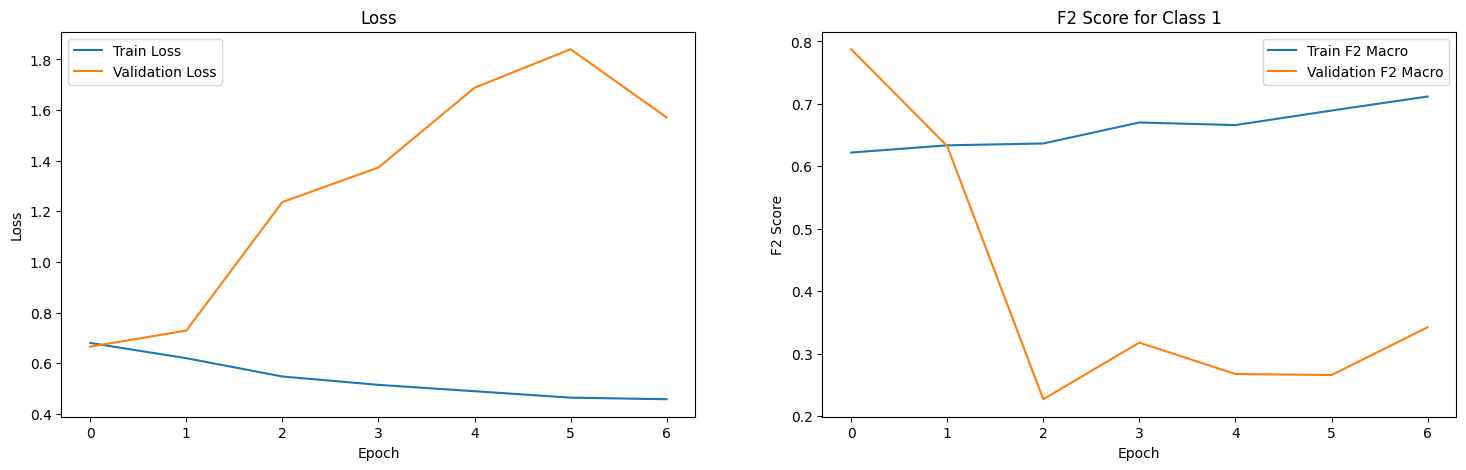

In [83]:
# Loss and F2 Visualisation
train_loss = [r["metrics"]["train_loss_history"][-1] for r in history ]
val_loss   = [r["metrics"]["val_loss_history"][-1] for r in history]
train_f2   = [r["metrics"]["train_f2_per_class_history"][-1][1] for r in history]
val_f2     = [r["metrics"]["val_f2_per_class_history"][-1][1] for r in history ]
epochs     = [x for x in range(len(history))]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
axes[0].plot(epochs, train_loss, label="Train Loss")
axes[0].plot(epochs, val_loss, label="Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(epochs, train_f2, label="Train F2 Macro")
axes[1].plot(epochs, val_f2, label="Validation F2 Macro")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F2 Score")
axes[1].set_title("F2 Score for Class 1")
axes[1].legend()